In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# Load the Fashion-MNIST dataset

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
# Define the clothing class names

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Number of classes:", len(class_names))
print("Clothing classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 10
Clothing classes:
0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


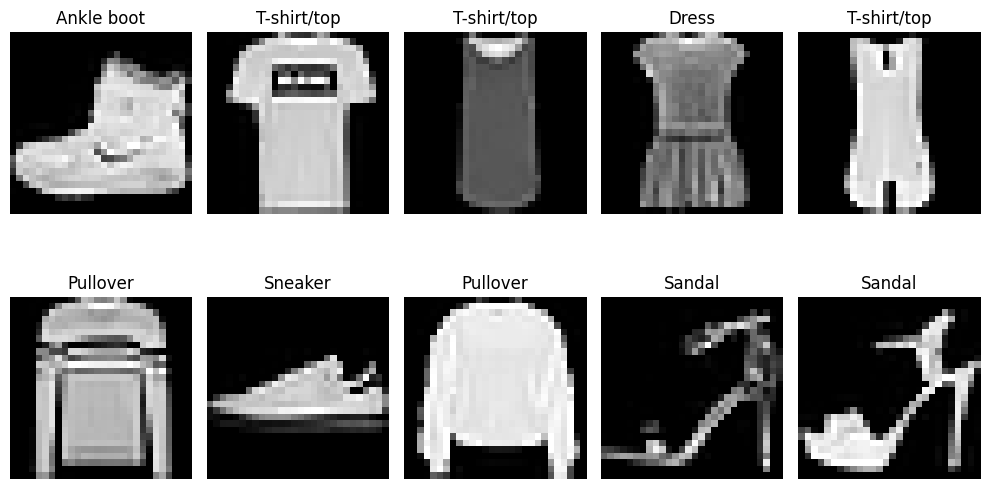

In [ ]:
# Display sample images from the dataset

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check pixel values before normalization

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value after normalization:", x_train.min())
print("Maximum pixel value after normalization:", x_train.max())

Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


In [ ]:
# Reshape images to include the grayscale channel

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [ ]:
# Build the Convolutional Neural Network (CNN)

model = tf.keras.Sequential([

    # Convolutional layer
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Second pooling layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a 1D vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Output layer - 10 clothing classes
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# Train the CNN model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7805 - loss: 0.6140 - val_accuracy: 0.8624 - val_loss: 0.3813
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8551 - loss: 0.4056 - val_accuracy: 0.8695 - val_loss: 0.3429
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8730 - loss: 0.3525 - val_accuracy: 0.8857 - val_loss: 0.3102
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8849 - loss: 0.3198 - val_accuracy: 0.8983 - val_loss: 0.2784
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8922 - loss: 0.2941 - val_accuracy: 0.8920 - val_loss: 0.2845
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9017 - loss: 0.2733 - val_accuracy: 0.9036 - val_loss: 0.2591
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9061 - loss: 0.2566 - val_accuracy: 0.9089 - val_loss: 0.2531
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9116 - loss: 0.2442 - val_accuracy: 0

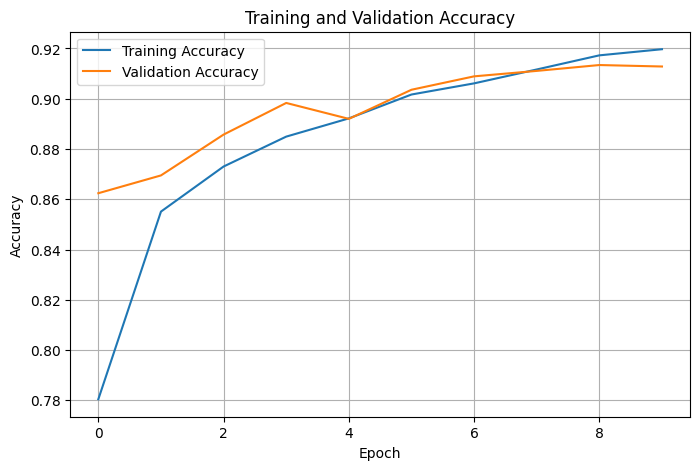

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

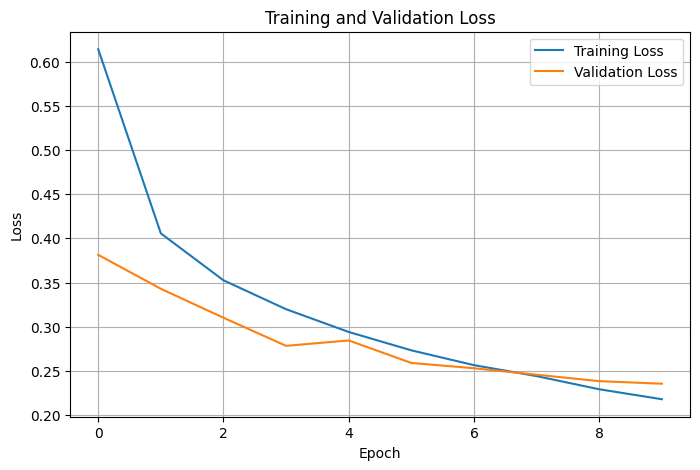

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9073 - loss: 0.2586
Test Loss: 0.2585865259170532
Test Accuracy: 0.9072999954223633


In [ ]:
# Generate predictions for the test images

predictions = model.predict(x_test)

print("Prediction shape:", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (10000, 10)


In [ ]:
# Convert prediction probabilities into predicted class labels

predicted_labels = np.argmax(predictions, axis=1)

print("First 10 predicted labels:")
print(predicted_labels[:10])

print("First 10 actual labels:")
print(y_test[:10])

First 10 predicted labels:
[9 2 1 1 6 1 4 6 5 7]
First 10 actual labels:
[9 2 1 1 6 1 4 6 5 7]


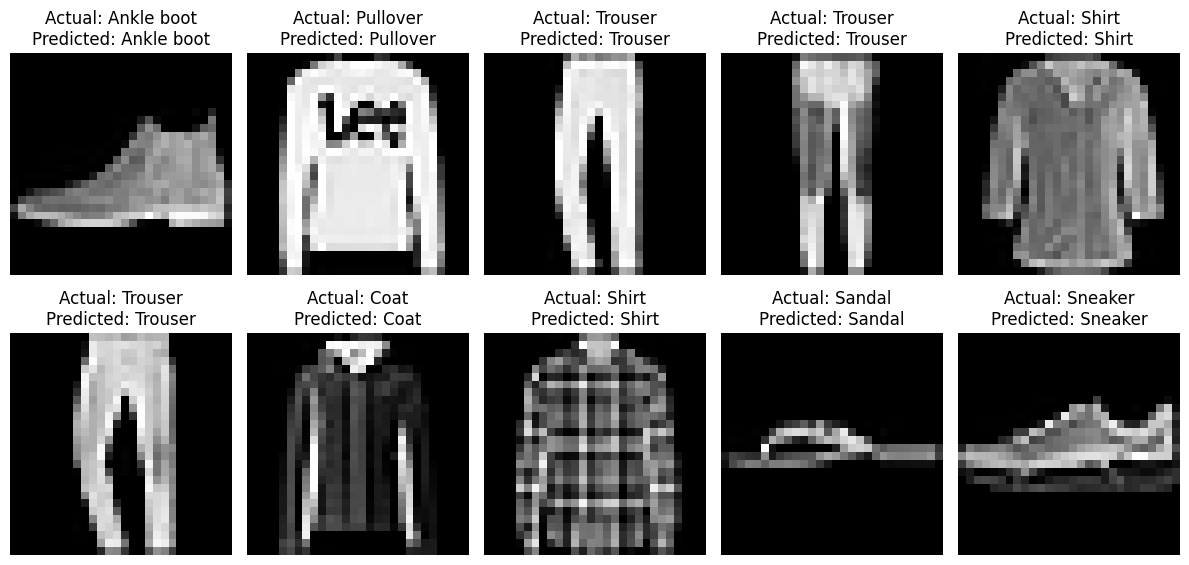

In [ ]:
# Visualize actual vs predicted labels

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_labels[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[899   0  15  14   2   1  65   0   3   1]
 [  2 975   0  13   4   1   3   0   2   0]
 [ 17   0 806   7  86   0  83   0   1   0]
 [ 20   4   9 905  34   0  26   0   2   0]
 [  1   1  16  19 897   0  66   0   0   0]
 [  0   0   0   0   0 983   0   8   0   9]
 [145   1  50  25  73   0 702   0   4   0]
 [  0   0   0   0   0   9   0 961   0  30]
 [  5   0   1   3   2   2   4   4 979   0]
 [  0   0   0   0   0   4   1  29   0 966]]


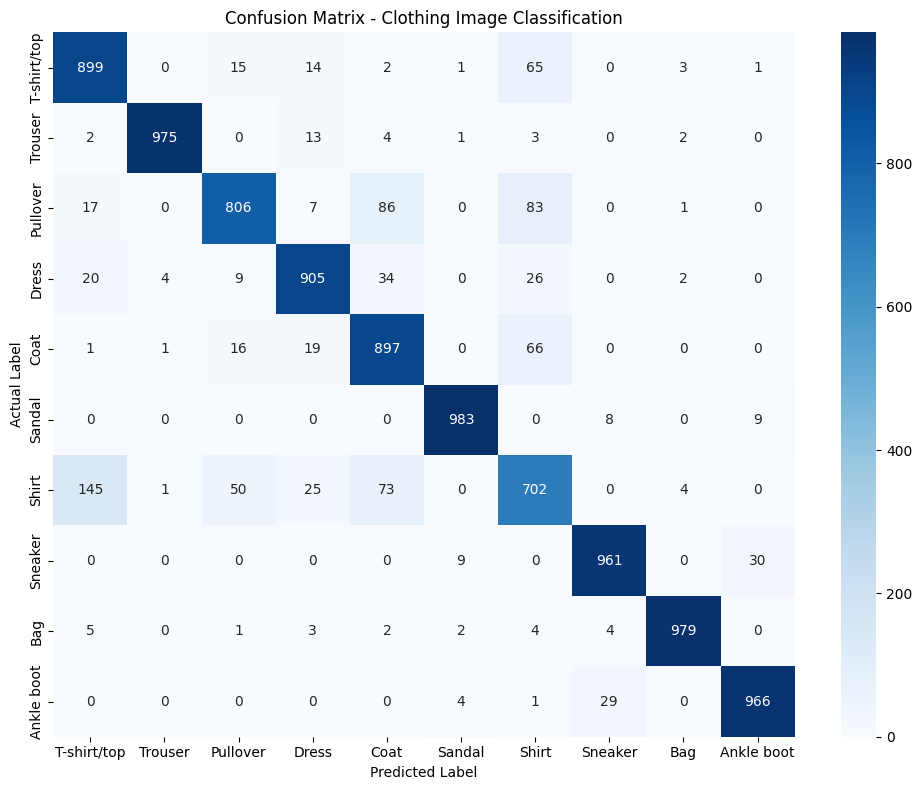

In [ ]:
# Visualize the confusion matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Clothing Image Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [ ]:
# Find incorrectly classified images

incorrect_indices = np.where(predicted_labels != y_test)[0]

print("Total incorrect predictions:", len(incorrect_indices))
print("Total correct predictions:", len(y_test) - len(incorrect_indices))

Total incorrect predictions: 927
Total correct predictions: 9073


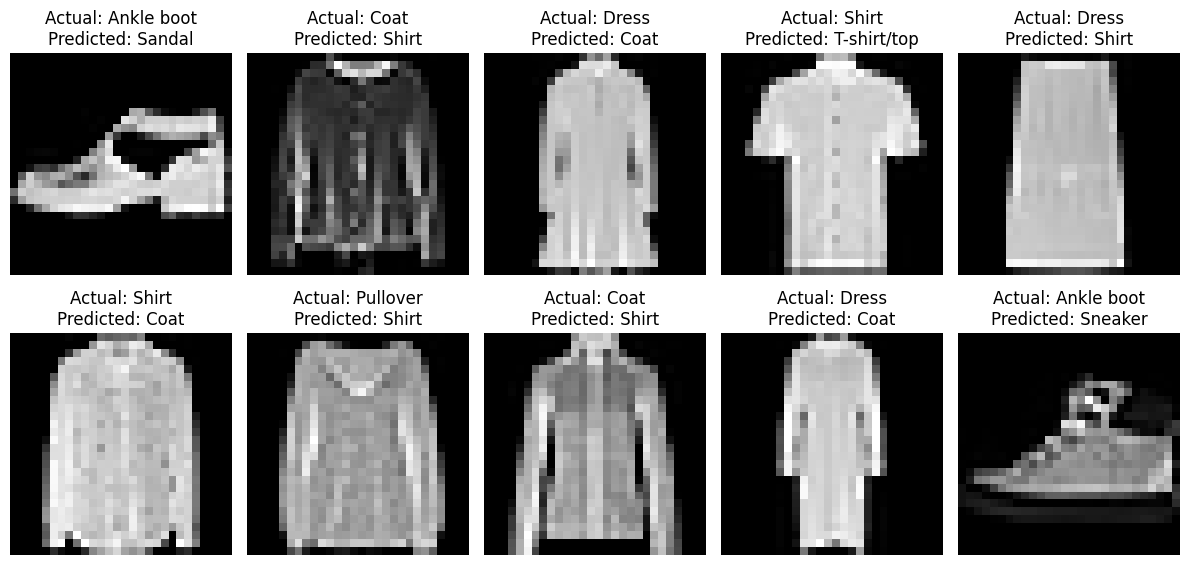

In [ ]:
# Display incorrectly classified images

plt.figure(figsize=(12, 6))

for i in range(10):
    index = incorrect_indices[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index].squeeze(), cmap="gray")

    actual = class_names[y_test[index]]
    predicted = class_names[predicted_labels[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Generate classification report

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.90      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.90      0.81      0.85      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.82      0.90      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.70      0.72      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
# Save the trained CNN model

model.save("clothing_image_classifier.keras")

print("Model saved successfully as clothing_image_classifier.keras")

Model saved successfully as clothing_image_classifier.keras


In [ ]:
# Load the saved model

loaded_model = tf.keras.models.load_model("clothing_image_classifier.keras")

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [ ]:
# Verify predictions using the loaded model

loaded_predictions = loaded_model.predict(x_test[:10], verbose=0)
loaded_labels = np.argmax(loaded_predictions, axis=1)

print("Predictions from loaded model:")
print(loaded_labels)

print("\nActual labels:")
print(y_test[:10])

print("\nPredictions match original model:",
      np.array_equal(loaded_labels, predicted_labels[:10]))

Predictions from loaded model:
[9 2 1 1 6 1 4 6 5 7]

Actual labels:
[9 2 1 1 6 1 4 6 5 7]

Predictions match original model: True
